In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Deshabilitar el uso de GPU

import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping 

# 1. Agregas la ruta absoluta de la carpeta externa al sistema de Python
ruta_externa = '/home/asus_juan/Documents/GitHub/Despliegue-modelo-ANN-Turbinas-Hidraulicas/scripts/scr'
sys.path.append(ruta_externa)

from cargar_datos import cargar_datos_from_excel
from ft_engineering import ft_engineering, split_to_model

/home/asus_juan/Documents/GitHub/Despliegue-modelo-ANN-Turbinas-Hidraulicas/.ANN_Env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1776111868.738935  549029 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776111869.075103  549029 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776111870.616956  549029 port.cc:153] oneDNN custom operations are on. Y

In [3]:
df = cargar_datos_from_excel(excel_path='/home/asus_juan/Documents/GitHub/Despliegue-modelo-ANN-Turbinas-Hidraulicas/database/data_scr/30Hz_Data.xlsx', sheet_name='MODELO_30HZ_MLP')

# Listas de los features a procesar
numerics = ['Torque [Nm]', 'RPM ', 'Caudal [lt/s ]', 'Presion (PsiD)', 'Presion (PsiG)']
categorical = ['Frecuencia']
droping_feat = ['EXPERIMENTO_ID'] # Variables innesarias

Pipeline = ft_engineering(var_num=numerics, var_cat=categorical, drop_var=droping_feat, quantile=0.05)
X_train, X_test, y_train, y_test = split_to_model(df, target='Power [kW]', stratify=False)

Pipeline.fit(X_train, y_train)

X_train_transformed = Pipeline.transform(X_train)
X_test_transformed = Pipeline.transform(X_test)
print(f"Número de columnas finales para la Red Neuronal: {X_train_transformed.shape[1]}")

Cargados 1785 datos
Variables successfully separated — X: 1785 rows, y: 1785 rows
Train split size: 1428
Test split size:  357
Número de columnas finales para la Red Neuronal: 6


In [4]:
# Creamos la arquitectura de la red Neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_transformed.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1,  activation='linear')  # Capa de salida para regresión
])

# Creamos el modelo para la metrica de evaluacion usamos MAE (Median Absolute Error)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entreamos el modelo
history = model.fit(
    X_train_transformed,
    y_train,
    validation_split = 0.2,
    epochs=150,
    batch_size=32,
    verbose=1
)

# Evaluamos el modelo para ver que tal funciona
loss, mae = model.evaluate(X_test_transformed, y_test)
print(f"Error Absoluto Medio (MAE) en datos de prueba: {mae:.2f} Watts")

Epoch 1/150


E0000 00:00:1776111871.479650  549029 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3600.5667 - mae: 51.4208 - val_loss: 3767.1140 - val_mae: 52.7460
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3342.3796 - mae: 49.2214 - val_loss: 3355.6448 - val_mae: 49.5906
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2767.3984 - mae: 44.8173 - val_loss: 2538.3848 - val_mae: 43.2981
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1876.3331 - mae: 37.4240 - val_loss: 1539.7922 - val_mae: 34.4303
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1135.9623 - mae: 29.6411 - val_loss: 1002.0765 - val_mae: 28.0666
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 896.7402 - mae: 25.9089 - val_loss: 892.7651 - val_mae: 25.9297
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 843.7164 - mae: 24.9980 - val_loss: 842.2147 - val_mae: 25.1388
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 796.3079 - mae: 24.3035 - val_loss: 798.8129 - val_mae: 24.5299
Epoch 9/150
36/36 

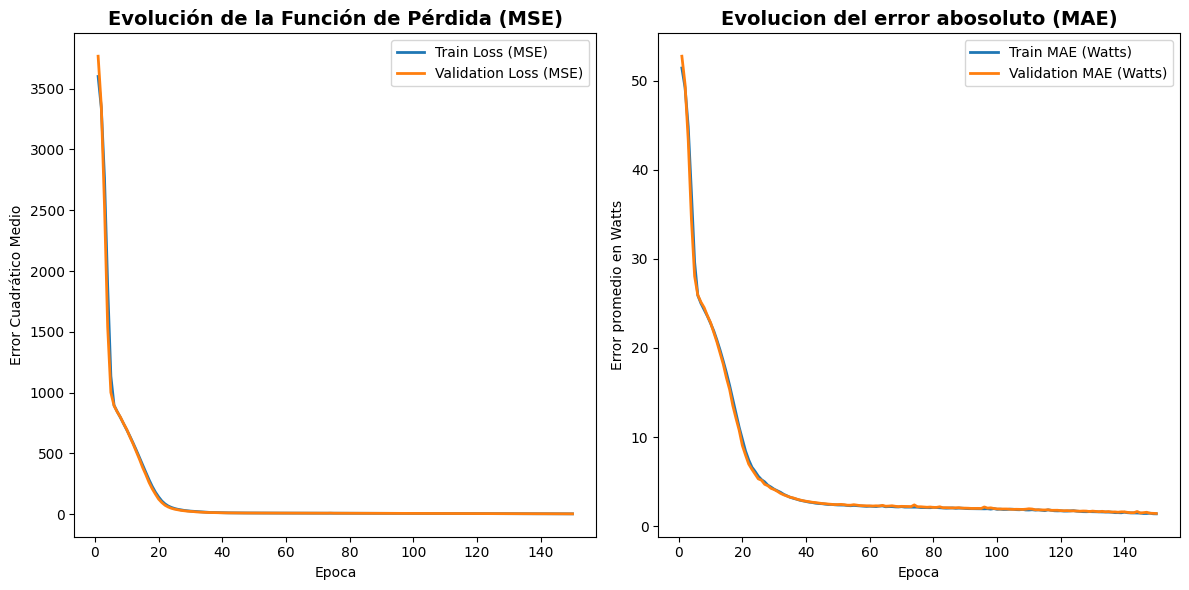

In [5]:
# Graficas de evaluacion del MAE 
history_df = pd.DataFrame(history.history)
history_df['Epoca'] = history_df.index + 1

fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.lineplot(data=history_df, x='Epoca', y='loss', label='Train Loss (MSE)', ax=ax[0], linewidth=2)
sns.lineplot(data=history_df, x='Epoca', y='val_loss', label='Validation Loss (MSE)', ax=ax[0], linewidth=2)
ax[0].set_title('Evolución de la Función de Pérdida (MSE)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Error Cuadrático Medio')

sns.lineplot(data=history_df, x='Epoca', y='mae', label='Train MAE (Watts)', ax=ax[1], linewidth=2)
sns.lineplot(data=history_df, x='Epoca', y='val_mae', label='Validation MAE (Watts)', ax=ax[1], linewidth=2)
ax[1].set_title('Evolucion del error abosoluto (MAE)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Error promedio en Watts')

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


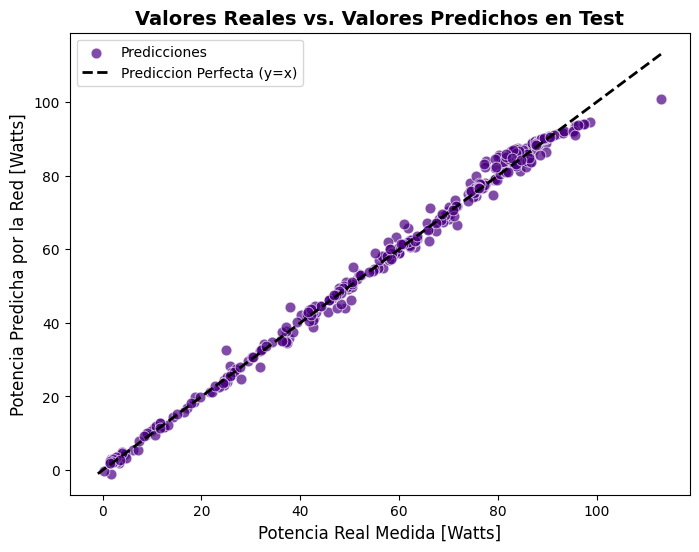

In [6]:
# Creamos una regresion con los valores que predijo la maquina vs los reales
y_pred = model.predict(X_test_transformed).flatten()

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='indigo', s=60, label='Predicciones')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
sns.lineplot(x=[min_val, max_val], y=[min_val, max_val], color='black', linestyle='--', linewidth=2, label='Prediccion Perfecta (y=x)')

plt.title('Valores Reales vs. Valores Predichos en Test', fontsize=14, fontweight='bold')
plt.xlabel('Potencia Real Medida [Watts]', fontsize=12)
plt.ylabel('Potencia Predicha por la Red [Watts]', fontsize=12)
plt.legend(loc='upper left')
plt.show()

In [7]:
# Optuna es una libreria para hacer estudios de hiperparametros y busqueda de optimizacion

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3) # Probará entre 1 y 3 capas ocultas
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True) # Tasa de aprendizaje
    
    # Para que Optuna pueda evaluar en varios casos de arquitectura creamos una secuencia variable
    model = Sequential()
    # Entrada de cantidad de neuronas de entrada dependiendo del df
    model.add(Input(shape=(X_train_transformed.shape[1],)))
    
    # Iteramos para que haga el analisis en varias capas y la cantidad de neuronas en cada capa
    for i in range(n_layers):
        # Sugerir neuronas por capa (en múltiplos de 16 para eficiencia de memoria)
        units = trial.suggest_int(f'n_units_l{i}', 16, 128, step=16)
        # Sugerir la función de activación 
        activation = trial.suggest_categorical(f'activation_l{i}', ['relu', 'swish', 'tanh'])
        
        # Se agregan las neuronas que va haciendo optuna a la densidad de capa
        model.add(Dense(units, activation=activation))
        
        # Sugerir Dropout para evitar Overfitting (apagar entre 0% y 30% de neuronas)
        dropout_rate = trial.suggest_float(f'dropout_l{i}', 0.0, 0.3)
        model.add(Dropout(dropout_rate))
        
    # Capa de salida (1 neurona para la potencia)
    model.add(Dense(1, activation='linear'))
    
    # 3. Compilar el modelo
    model.compile(
        optimizer=Adam(learning_rate=learning_rate), 
        loss='mse', 
        metrics=['mae']
    )
    
    # 4. Entrenar el modelo (con EarlyStopping para no perder tiempo si el modelo es malo)
    early_stop = EarlyStopping(
        monitor='val_mae', 
        patience=15,               # Si no mejora en 15 epochs, detiene esa prueba
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train_transformed, y_train,
        validation_data=(X_test_transformed, y_test),
        epochs=200,                # Es necesario usar bastantes Epochs para tener buenos resultados
        batch_size=32,
        callbacks=[early_stop],
        verbose=0                  # Eso para evitar mostrar el desorden en la salida
    )
    
    # Retornar la métrica que queremos minimizar (Validación MAE)
    val_mae = min(history.history['val_mae'])
    return val_mae

# Optuna se ejecuta mediante un estudio de los hiperparameros y se le dan n trials
print("Iniciando la cacería de hiperparámetros con Optuna...")
study = optuna.create_study(direction='minimize', study_name="Optimizacion_Turbina_ANN")

# Lo voy a poner en 30 hasta poder ejecutarlo en un mejor PC
study.optimize(objective, n_trials=30)

print("\n" + "="*45)
print("¡Optimización Finalizada!")
print("Mejor MAE alcanzado:", study.best_value)
print("Mejores hiperparámetros:", study.best_params)
print("="*45)

[I 2026-04-13 15:24:47,058] A new study created in memory with name: Optimizacion_Turbina_ANN


Iniciando la cacería de hiperparámetros con Optuna...


[I 2026-04-13 15:25:08,027] Trial 0 finished with value: 4.6980743408203125 and parameters: {'n_layers': 1, 'learning_rate': 0.0012443712850334775, 'n_units_l0': 16, 'activation_l0': 'tanh', 'dropout_l0': 0.23039796295753223}. Best is trial 0 with value: 4.6980743408203125.
[I 2026-04-13 15:25:20,421] Trial 1 finished with value: 1.0138778686523438 and parameters: {'n_layers': 2, 'learning_rate': 0.0016624732310986786, 'n_units_l0': 128, 'activation_l0': 'relu', 'dropout_l0': 0.2991085236019932, 'n_units_l1': 128, 'activation_l1': 'swish', 'dropout_l1': 0.15429444541124487}. Best is trial 1 with value: 1.0138778686523438.
[I 2026-04-13 15:25:41,781] Trial 2 finished with value: 29.163949966430664 and parameters: {'n_layers': 1, 'learning_rate': 0.00024897940380565225, 'n_units_l0': 16, 'activation_l0': 'tanh', 'dropout_l0': 0.15786169216854984}. Best is trial 1 with value: 1.0138778686523438.
[I 2026-04-13 15:26:14,120] Trial 3 finished with value: 19.247583389282227 and parameters: {'


¡Optimización Finalizada!
Mejor MAE alcanzado: 0.5385718941688538
Mejores hiperparámetros: {'n_layers': 2, 'learning_rate': 0.007791820752228083, 'n_units_l0': 128, 'activation_l0': 'swish', 'dropout_l0': 0.005368178594799405, 'n_units_l1': 16, 'activation_l1': 'swish', 'dropout_l1': 0.009761530144541643}


In [8]:
# CONSTRUCCIÓN DEL MODELO OPTIMIZADO

modelo_final = Sequential([
    # Para que sea dinamico y variable usamos el shape de X_train_transformed que es el df que le pasamos al modelo final
    Input(shape=(X_train_transformed.shape[1],)),
    
    # Capa Oculta 1 (Usamos los parametros de Optuna)
    Dense(96, activation='tanh'),
    Dropout(0.0029198674), 
    
    # Capa Oculta 2 (Parámetros de Optuna)
    Dense(48, activation='swish'),
    Dropout(0.0169671718),
    
    # Capa de Salida (Predicción de Potencia en kW)
    Dense(1, activation='linear')
])

# Usamos el Learning Rate exacto encontrado por Optuna
optimizador_adam = Adam(learning_rate=0.0026005625087794477)

modelo_final.compile(
    optimizer=optimizador_adam,
    loss='mse',
    metrics=['mae']
)

# Mostramos la arquitectura final del modelo
print("Arquitectura del Modelo Final:")
modelo_final.summary()

# Volvemos a usar EarlyStopping para quedarnos con los mejores pesos
early_stop_final = EarlyStopping(
    monitor='val_mae', 
    patience=20, 
    restore_best_weights=True
)

print("\nEntrenando el modelo final...")
history_final = modelo_final.fit(
    X_train_transformed, y_train,
    validation_data=(X_test_transformed, y_test),
    epochs=200,          # Dejamos margen suficiente
    batch_size=32,
    callbacks=[early_stop_final],
    verbose=1            # Ahora sí queremos ver cómo baja el error
)

# Evaluamos el modelo para ver que tal funciona
loss, mae = modelo_final.evaluate(X_test_transformed, y_test)
print(f"Error Absoluto Medio (MAE) en datos de prueba: {mae:.2f} Watts")

Arquitectura del Modelo Final:


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_92 (Dense)                │ (None, 96)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo final...
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2216.9089 - mae: 39.1646 - val_loss: 933.5007 - val_mae: 24.9583
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 932.3661 - mae: 26.0142 - val_loss: 845.8881 - val_mae: 24.8729
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 879.7532 - mae: 25.5051 - val_loss: 798.8641 - val_mae: 24.1898
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 813.2619 - mae: 24.5618 - val_loss: 679.0276 - val_mae: 22.5127
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 575.2361 - mae: 20.5983 - val_loss: 332.0262 - val_mae: 15.7834
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 172.6481 - mae: 10.3969 - val_loss: 55.3734 - val_mae: 5.7267
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38.7665 - mae: 4.9882 - val_loss: 23.8575 - val_mae: 3.9969
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25.5692 - mae: 4.0780 - val_loss: 17.3788 - val_mae: 3

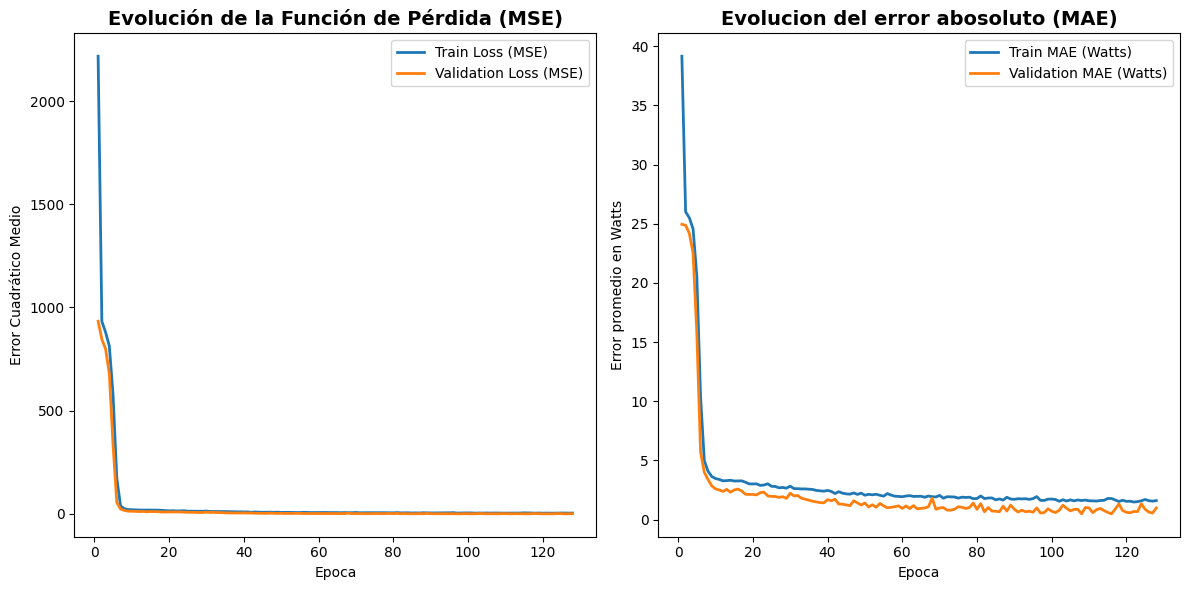

In [9]:
# Graficas de evaluacion del MAE 
history_df = pd.DataFrame(history_final.history)
history_df['Epoca'] = history_df.index + 1

fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.lineplot(data=history_df, x='Epoca', y='loss', label='Train Loss (MSE)', ax=ax[0], linewidth=2)
sns.lineplot(data=history_df, x='Epoca', y='val_loss', label='Validation Loss (MSE)', ax=ax[0], linewidth=2)
ax[0].set_title('Evolución de la Función de Pérdida (MSE)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Error Cuadrático Medio')

sns.lineplot(data=history_df, x='Epoca', y='mae', label='Train MAE (Watts)', ax=ax[1], linewidth=2)
sns.lineplot(data=history_df, x='Epoca', y='val_mae', label='Validation MAE (Watts)', ax=ax[1], linewidth=2)
ax[1].set_title('Evolucion del error abosoluto (MAE)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Error promedio en Watts')

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


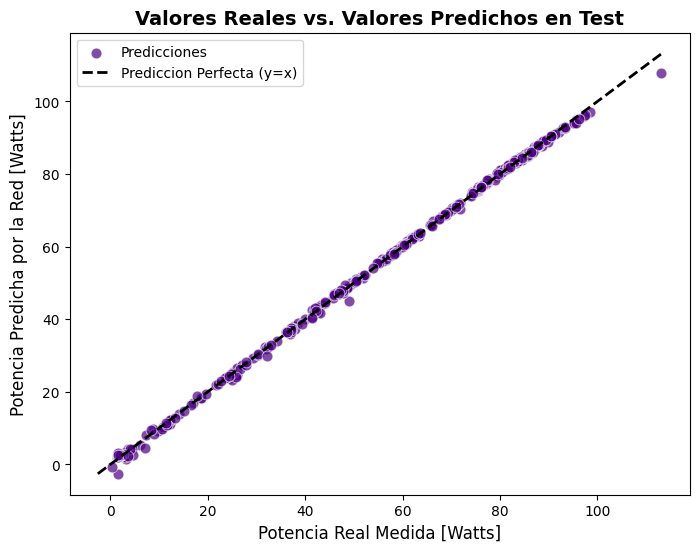

In [10]:
# Creamos una regresion con los valores que predijo la maquina vs los reales
y_pred = modelo_final.predict(X_test_transformed).flatten()

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='indigo', s=60, label='Predicciones')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
sns.lineplot(x=[min_val, max_val], y=[min_val, max_val], color='black', linestyle='--', linewidth=2, label='Prediccion Perfecta (y=x)')

plt.title('Valores Reales vs. Valores Predichos en Test', fontsize=14, fontweight='bold')
plt.xlabel('Potencia Real Medida [Watts]', fontsize=12)
plt.ylabel('Potencia Predicha por la Red [Watts]', fontsize=12)
plt.legend(loc='upper left')
plt.show()

In [11]:
# Creamos un diccionario directamente con los valores del caso extremo
datos_entrada = {
    'Torque [Nm]': 0.211,
    'RPM ': 730,  
    'Frecuencia': '30_Hz',
    'Caudal [lt/s ]': 8.9453,
    'Presion (PsiD)': 2.3565,
    'Presion (PsiG)': 2.2434
}

# Lo convertimos a un DataFrame de una sola fila
caso_especifico = pd.DataFrame([datos_entrada])

# Alineamos las columnas para que sean EXACTAMENTE iguales a X_train
# Si falta alguna columna que existía en X_train, se rellena con 0.0 automáticamente
caso_especifico = caso_especifico.reindex(columns=X_train.columns, fill_value=0.0)

# Transformamos usando el Pipeline ya ajustado
caso_transformado = Pipeline.transform(caso_especifico)

# Predicción
prediccion_kw = model.predict(caso_transformado)

# Impresión de Resultados
print("\n" + "="*45)
print(" RESULTADO DEL CASO")
print("="*45)
print("Parámetros de entrada de la turbina:")
print(f" - RPM: {caso_especifico.loc[0, 'RPM ']:.0f}")
print(f" - Torque [Nm]: {caso_especifico.loc[0, 'Torque [Nm]']}")
print(f" - Caudal [lt/s]: {caso_especifico.loc[0, 'Caudal [lt/s ]']}")
    
# Formateo correcto de unidades
kw_result = prediccion_kw[0][0]
watts_result = kw_result * 1000

print(f"\n POTENCIA GENERADA PREDICHA: {kw_result:.4f} kW ({watts_result:.1f} Watts)")
print("="*45)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

 RESULTADO DEL CASO
Parámetros de entrada de la turbina:
 - RPM: 730
 - Torque [Nm]: 0.211
 - Caudal [lt/s]: 8.9453

 POTENCIA GENERADA PREDICHA: 17.3242 kW (17324.2 Watts)


In [12]:
# Creamos un diccionario directamente con los valores del caso extremo
datos_entrada = {
    'Torque [Nm]': 0.211,
    'RPM ': 730,  
    'Frecuencia': '30_Hz',
    'Caudal [lt/s ]': 8.9453,
    'Presion (PsiD)': 2.3565,
    'Presion (PsiG)': 2.2434
}

# Lo convertimos a un DataFrame de una sola fila
caso_especifico = pd.DataFrame([datos_entrada])

# Alineamos las columnas para que sean EXACTAMENTE iguales a X_train
# Si falta alguna columna que existía en X_train, se rellena con 0.0 automáticamente
caso_especifico = caso_especifico.reindex(columns=X_train.columns, fill_value=0.0)

# Transformamos usando el Pipeline ya ajustado
caso_transformado = Pipeline.transform(caso_especifico)

# Predicción
prediccion_kw = modelo_final.predict(caso_transformado)

# Impresión de Resultados
print("\n" + "="*45)
print(" RESULTADO DEL CASO")
print("="*45)
print("Parámetros de entrada de la turbina:")
print(f" - RPM: {caso_especifico.loc[0, 'RPM ']:.0f}")
print(f" - Torque [Nm]: {caso_especifico.loc[0, 'Torque [Nm]']}")
print(f" - Caudal [lt/s]: {caso_especifico.loc[0, 'Caudal [lt/s ]']}")
    
# Formateo correcto de unidades
kw_result = prediccion_kw[0][0]
watts_result = kw_result * 1000

print(f"\n POTENCIA GENERADA PREDICHA: {kw_result:.4f} kW ({watts_result:.1f} Watts)")
print("="*45)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

 RESULTADO DEL CASO
Parámetros de entrada de la turbina:
 - RPM: 730
 - Torque [Nm]: 0.211
 - Caudal [lt/s]: 8.9453

 POTENCIA GENERADA PREDICHA: 15.6379 kW (15637.9 Watts)
